# Dataset Transaksi Utama

## Menentukan Pertanyaan Bisnis

  * Bagaimana distribusi pengeluaran user berdasarkan kategori dalam 3 bulan terakhir?
  * Kategori apa yang mengalami peningkatan pengeluaran terbesar dari bulan ke bulan?
  * Pada hari apa transaksi paling sering terjadi?
  * Berapa rata-rata pengeluaran harian user dan bagaimana perubahannya dari waktu ke waktu?
  * Kapan waktu paling berisiko user mengalami lonjakan pengeluaran?
  * Apakah terdapat perbedaan rata-rata pengeluaran berdasarkan metode pembayaran?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

## Data Wrangling

### Gathering Data

In [2]:
# load dataset transaksi
file_id = "1RRX2QmOKSCTkgDa8hp4XLcKcw1-DeAAQ"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(url)

# melihat data awal
df.head()

,transaction_id,user_id,date,merchant,amount,category_detail,category_primary,payment_method,payment_media
0,TXN000001,USR055,2024-10-03 20:33:48,Santika Hotel,685500,travel,Wants,Transfer,BSI
1,TXN000002,USR064,2024-12-03 05:09:38,SPA Reflexology,166000,self_care,Wants,Transfer,Gopay
2,TXN000003,USR043,2024-02-19 20:15:58,RedDoorz,901500,travel,Wants,Credit Card,BRI
3,TXN000004,USR041,2023-11-18 01:04:49,Adobe Creative Cloud,192500,education,Wants,Transfer,Jenius
4,TXN000005,USR041,2024-01-05 19:15:44,Smartfren,65000,utilities,Needs,QRIS,BRI


### Asessing Data

In [3]:
# cek dimensi dataset
df.shape

(10050, 9)

In [4]:
# cek tipe data dan jumlah non-null tiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    10050 non-null  object
 1   user_id           10050 non-null  object
 2   date              9914 non-null   object
 3   merchant          9904 non-null   object
 4   amount            9802 non-null   object
 5   category_detail   9957 non-null   object
 6   category_primary  9866 non-null   object
 7   payment_method    10050 non-null  object
 8   payment_media     10050 non-null  object
dtypes: object(9)
memory usage: 706.8+ KB


In [5]:
# cek missing values (NaN) per kolom
df.isnull().sum()

,0
transaction_id,0
user_id,0
date,136
merchant,146
amount,248
category_detail,93
category_primary,184
payment_method,0
payment_media,0


In [6]:
# cek duplikasi baris penuh
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 0


In [7]:
# cek inkonsistensi nilai kategorikal
for col in ['merchant', 'category_detail', 'category_primary', 'payment_method', 'payment_media']:
    print(f"\n{col}:", df[col].unique())


merchant: ['Santika Hotel' 'SPA Reflexology' 'RedDoorz' 'Adobe Creative Cloud'
 'Smartfren' 'Alfamidi' 'Skill Academy' 'Netflix' 'Mobile Legends'
 'Cult Fitness' 'Starbucks' 'Steam' 'fore coffee' 'Halodoc' 'Tokocrypto'
 'AirAsia' 'Citilink' 'Gong Cha' 'Pintu Crypto' 'Innisfree' 'Ruangguru'
 'First Media' 'PDAM' 'Luxcrime' 'Lawson' 'MyXL' 'Pertamina' 'Stockbit'
 'Shell' 'Hypermart' 'Nintendo eShop' 'Adidas' 'Udemy' 'A&W'
 'Xbox Game Pass' 'Roblox' 'Microsoft 365' 'Fit Hub' 'Somethinc' 'Airbnb'
 'Indomaret' 'PLN Mobile' 'Gojek' 'Zenius' 'Es Teh Indonesia' 'Dicoding'
 'Indodax' 'Free Fire' 'Pluang' 'Watson' 'Daiso' 'Bath & Body Works'
 'Wardah' 'Booking.com' 'Figma' 'Kimia Farma' 'Carrefour'
 'Nasi Goreng Pak Nasir' 'Ajaib' 'Google One Storage' 'Garuda Indonesia'
 'Alfamart' 'Vidio' 'iPot' 'BPJS Kesehatan' 'New Balance' 'Mumuso'
 'Cotton On' 'Maxim' 'Tiket.com' 'Apple Music' 'Bakso' 'Lion Air'
 'Scarlett Whitening' 'Subway' 'Shopee' 'Converse' 'Matahari' 'Grab'
 'The Body Shop' 'halodoc'

In [8]:
# Deteksi inkonsistensi format tanggal
date_sample = df['date'].dropna().astype(str)

fmt_ddmmyyyy   = date_sample.str.match(r'^\d{2}/\d{2}/\d{4}').sum()
fmt_yyyymmdd_s = date_sample.str.match(r'^\d{4}/\d{2}/\d{2}').sum()
fmt_yyyymmdd_d = date_sample.str.match(r'^\d{4}-\d{2}-\d{2}').sum()

print(f'DD/MM/YYYY HH:MM : {fmt_ddmmyyyy} baris')
print(f'YYYY/MM/DD HH:MM:SS: {fmt_yyyymmdd_s} baris')
print(f'YYYY-MM-DD HH:MM:SS (standar) : {fmt_yyyymmdd_d} baris')

DD/MM/YYYY HH:MM : 414 baris
YYYY/MM/DD HH:MM:SS: 305 baris
YYYY-MM-DD HH:MM:SS (standar) : 9195 baris


In [9]:
# Deteksi inkonsistensi format kolom 'amount'
non_numeric = df[pd.to_numeric(df['amount'], errors='coerce').isna() & df['amount'].notna()]
print(f'Baris amount non-numerik : {len(non_numeric)}')
print(non_numeric[['transaction_id', 'amount']].head(10))

Baris amount non-numerik : 70
     transaction_id     amount
111       TXN000112   534000rb
137       TXN000138   145000rb
286       TXN000287    65000rb
424       TXN000425   190500rb
658       TXN000659   488500rb
965       TXN000966   411000rb
1109      TXN001110   118000rb
1258      TXN001259   434500rb
1367      TXN001368    88000rb
1370      TXN001371  1156000rb


**Insight:**
- Missing values tersebar di 6 kolom: `date`, `merchant`, `amount`, `category_detail`, `category_primary`, `payment_media`
- `category_detail` memiliki inkonsistensi kapitalisasi (`food` vs `FOOD` vs `Food`)
- Kolom `date` menggunakan 3 format berbeda, perlu standarisasi ke datetime
- Kolom `amount` ada yang berformat string (`85000rb`, `85000.00`), perlu dibersihkan

### Cleaning Data


In [10]:
# Membuat salinan agar data asli tetap terjaga
df_clean = df.copy()

In [11]:
# Bersihkan & konversi kolom 'amount'
def clean_amount(val):
    if pd.isna(val) or str(val).strip() == '': return np.nan
    val = str(val).strip().replace('rb', '').replace(',', '')
    try:    return float(val)
    except: return np.nan

df_clean['amount'] = df_clean['amount'].apply(clean_amount)

before = len(df_clean)
df_clean.dropna(subset=['amount'], inplace=True)
df_clean['amount'] = df_clean['amount'].astype(float)
print(f'Baris amount invalid dihapus : {before - len(df_clean)} | Sisa : {len(df_clean)}')

Baris amount invalid dihapus : 248 | Sisa : 9802


In [12]:
# Standarisasi & konversi kolom 'date' ke datetime
# Format yang distandarisasi :
#   YYYY-MM-DD HH:MM:SS  (standar)

def parse_date(val):
    if pd.isna(val) or str(val).strip() == '': return pd.NaT
    for fmt in ('%Y-%m-%d %H:%M:%S', '%d/%m/%Y %H:%M', '%Y/%m/%d %H:%M:%S',
                '%Y-%m-%d', '%d/%m/%Y'):
        try:    return pd.to_datetime(val, format=fmt)
        except: continue
    return pd.NaT

df_clean['date'] = df_clean['date'].apply(parse_date)

before = len(df_clean)
df_clean.dropna(subset=['date'], inplace=True)
df_clean = df_clean[df_clean['date'] <= pd.Timestamp('2025-01-01')].copy()
print(f'Baris date tidak valid dihapus : {before - len(df_clean)} | Sisa : {len(df_clean)}')
print(f'Tipe kolom date : {df_clean["date"].dtype}')

Baris date tidak valid dihapus : 131 | Sisa : 9671
Tipe kolom date : datetime64[ns]


In [13]:
# Standarisasi category_detail → lowercase
valid_categories = {
    'food', 'transport', 'shopping', 'groceries', 'entertainment',
    'health', 'education', 'utilities', 'investment', 'self_care', 'travel'
}

df_clean['category_detail'] = df_clean['category_detail'].str.strip().str.lower()

before = len(df_clean)
df_clean.dropna(subset=['category_detail'], inplace=True)
df_clean = df_clean[df_clean['category_detail'].isin(valid_categories)].copy()
print(f'Nilai unik category_detail : {sorted(df_clean["category_detail"].unique())}')

Nilai unik category_detail : ['education', 'entertainment', 'food', 'groceries', 'health', 'investment', 'self_care', 'shopping', 'transport', 'travel', 'utilities']


In [14]:
# Isi ulang category_primary dari mapping
category_primary_map = {
    'food': 'Needs',       'transport': 'Needs',   'groceries': 'Needs',
    'utilities': 'Needs',  'health': 'Needs',
    'shopping': 'Wants',   'entertainment': 'Wants', 'self_care': 'Wants',
    'travel': 'Wants',     'education': 'Wants',
    'investment': 'Investment'
}

df_clean['category_primary'] = df_clean['category_detail'].map(category_primary_map)
print(df_clean['category_primary'].value_counts())

category_primary
Wants         4353
Needs         4328
Investment     898
Name: count, dtype: int64


In [15]:
# Perbaiki inkonsistensi payment_method vs payment_media
# Rule:
# Cash = payment_media wajib 'Cash'
mask_cash  = (df_clean['payment_method'] == 'Cash')  & (df_clean['payment_media'] != 'Cash')
df_clean.loc[mask_cash,  'payment_media'] = 'Cash'

In [16]:
# Standarisasi kapitalisasi → Title Case & strip spasi
df_clean['merchant'] = df_clean['merchant'].str.strip().str.title()

# Manual correction nama merchant dengan kapitalisasi khusus
merchant_fix = {
    'Spa Reflexology'   : 'SPA Reflexology',
    'Reddoorz'          : 'RedDoorz',
    'Pdam'              : 'PDAM',
    'Myxl'              : 'MyXL',
    'Pln Mobile'        : 'PLN Mobile',
    'Ipot'              : 'iPot',
    'Bpjs Kesehatan'    : 'BPJS Kesehatan',
    'Booking.Com'       : 'Booking.com',
    'Tiket.Com'         : 'Tiket.com',
    'Nintendo Eshop'    : 'Nintendo eShop',
    'J.Co Donuts'       : 'J.CO Donuts',
    'Kai Kereta Api'    : 'KAI Kereta Api',
    'Wetv'              : 'WeTV',
    'Cgv Cinemas'       : 'CGV Cinemas',
    'Lrt Jakarta'       : 'LRT Jakarta',
    'Cfc'               : 'CFC',
    'Krl Commuter'      : 'KRL Commuter',
    'Mytelkomsel'       : 'MyTelkomsel',
    'Mypertamina'       : 'MyPertamina',
    'Playstation Store' : 'PlayStation Store',
    'Indrive'           : 'inDrive',
    'Kfc'               : 'KFC',
    'Rs Siloam'         : 'RS Siloam',
    'Deposito Bca'      : 'Deposito BCA',
    'Mrt Jakarta'       : 'MRT Jakarta',
    'Xxi Cinema'        : 'XXI Cinema',
    'Pubg Mobile'       : 'PUBG Mobile',
    'Tiktok Shop'       : 'TikTok Shop',
    'Mcdonalds'         : 'McDonalds',
    'Bakmi Gm'          : 'Bakmi GM',
    "Wendy'S"           : "Wendy's",
    'Icloud Storage'    : 'iCloud Storage',
    'Airasia'           : 'AirAsia',
    'Oyo'               : 'OYO',
    'Youtube Premium'   : 'YouTube Premium',
    'Tabungan Bri'      : 'Tabungan BRI',
    'Familymart'        : 'FamilyMart',
    'Indihome'          : 'IndiHome',
}

df_clean['merchant'] = df_clean['merchant'].replace(merchant_fix)

# Hitung modus setelah koreksi nama
modus_merchant = df_clean['merchant'].mode()[0]
print(f'Modus merchant: {modus_merchant}')

# Isi string kosong / NaN dengan modus
df_clean['merchant'] = (
    df_clean['merchant']
    .replace('', float('nan'))
    .fillna(modus_merchant)
)

print('Jumlah merchant unik :', df_clean['merchant'].nunique())
print('Missing merchant     :', df_clean['merchant'].isnull().sum())

Modus merchant: MyXL
Jumlah merchant unik : 187
Missing merchant     : 0


In [17]:
print('RINGKASAN SETELAH CLEANING')
print(f'Shape              : {df_clean.shape}')
print(f'Missing values     : {df_clean.isnull().sum().sum()}')
print(f'Duplikat           : {df_clean.duplicated().sum()}')
print(f'Tipe date          : {df_clean["date"].dtype}')
print(f'Tipe amount        : {df_clean["amount"].dtype}')
df_clean.info()

RINGKASAN SETELAH CLEANING
Shape              : (9579, 9)
Missing values     : 0
Duplikat           : 0
Tipe date          : datetime64[ns]
Tipe amount        : float64
<class 'pandas.core.frame.DataFrame'>
Index: 9579 entries, 0 to 10049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9579 non-null   object        
 1   user_id           9579 non-null   object        
 2   date              9579 non-null   datetime64[ns]
 3   merchant          9579 non-null   object        
 4   amount            9579 non-null   float64       
 5   category_detail   9579 non-null   object        
 6   category_primary  9579 non-null   object        
 7   payment_method    9579 non-null   object        
 8   payment_media     9579 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 748.4+ KB


In [18]:
# Preview dataset bersih
df_clean.head(10)

,transaction_id,user_id,date,merchant,amount,category_detail,category_primary,payment_method,payment_media
0,TXN000001,USR055,2024-10-03 20:33:48,Santika Hotel,685500.0,travel,Wants,Transfer,BSI
1,TXN000002,USR064,2024-12-03 05:09:38,SPA Reflexology,166000.0,self_care,Wants,Transfer,Gopay
2,TXN000003,USR043,2024-02-19 20:15:58,RedDoorz,901500.0,travel,Wants,Credit Card,BRI
3,TXN000004,USR041,2023-11-18 01:04:49,Adobe Creative Cloud,192500.0,education,Wants,Transfer,Jenius
4,TXN000005,USR041,2024-01-05 19:15:44,Smartfren,65000.0,utilities,Needs,QRIS,BRI
5,TXN000006,USR008,2023-01-18 12:03:06,Alfamidi,216000.0,groceries,Needs,Cash,Cash
6,TXN000007,USR024,2023-03-10 17:29:59,Skill Academy,326000.0,education,Wants,Credit Card,CIMB Niaga
7,TXN000008,USR033,2024-07-11 10:02:44,Netflix,92000.0,entertainment,Wants,QRIS,ShopeePay
8,TXN000009,USR073,2023-10-08 17:14:01,Mobile Legends,183500.0,entertainment,Wants,Transfer,CIMB Niaga
9,TXN000010,USR042,2024-01-03 08:47:00,Cult Fitness,578000.0,health,Needs,Credit Card,Standard Chartered


In [19]:
# simpan dataset bersih
df_clean.to_csv("main_transactions_clean.csv", index=False)

## Exploratory Data Analysis

In [20]:
# Melihat Nama Kolom
df_clean.columns

Index(['transaction_id', 'user_id', 'date', 'merchant', 'amount',
       'category_detail', 'category_primary', 'payment_method',
       'payment_media'],
      dtype='object')

In [21]:
# Melihat Ukuran Dataset
print("Jumlah baris dan kolom:", df_clean.shape)

Jumlah baris dan kolom: (9579, 9)


In [22]:
df_clean.sample(5)

,transaction_id,user_id,date,merchant,amount,category_detail,category_primary,payment_method,payment_media
401,TXN000402,USR027,2023-04-20 02:55:19,LRT Jakarta,49500.0,transport,Needs,QRIS,LinkAja
3546,TXN003547,USR061,2023-02-09 08:26:12,Bath & Body Works,26500.0,self_care,Wants,Transfer,Mandiri
5592,TXN005593,USR002,2024-06-09 16:16:45,Vidio,84500.0,entertainment,Wants,Credit Card,Citibank
7849,TXN007850,USR046,2024-03-20 20:59:45,Circle K,104500.0,groceries,Needs,Debit,Jenius
10001,TXN010002,USR024,2023-11-11 22:50:33,Zenius,53000.0,education,Wants,Transfer,BRI


In [23]:
# Melihat Tipe Data
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9579 entries, 0 to 10049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9579 non-null   object        
 1   user_id           9579 non-null   object        
 2   date              9579 non-null   datetime64[ns]
 3   merchant          9579 non-null   object        
 4   amount            9579 non-null   float64       
 5   category_detail   9579 non-null   object        
 6   category_primary  9579 non-null   object        
 7   payment_method    9579 non-null   object        
 8   payment_media     9579 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 748.4+ KB


In [24]:
df_clean.describe()

,date,amount
count,9579,9.579000e+03
mean,2023-12-31 01:07:07.283432192,3.963223e+05
min,2022-12-27 00:18:13,4.000000e+03
25%,2023-07-02 10:14:25,7.700000e+04
50%,2023-12-30 12:25:24,2.115000e+05
75%,2024-07-01 16:39:24,4.522500e+05
max,2024-12-31 23:28:44,2.498000e+06
std,NaN,4.987549e+05


**Insight**

Dataset clean transaksi terdiri dari 9.579 data dengan 9 fitur utama yang mencakup informasi transaksi, pengguna, kategori pengeluaran, metode pembayaran, dan nominal transaksi. Seluruh kolom tidak memiliki missing value sehingga dataset berada dalam kondisi yang baik untuk proses analisis lebih lanjut. Berdasarkan statistik deskriptif, rata-rata nominal transaksi pengguna berada pada kisaran Rp396 ribu dengan nilai transaksi minimum sebesar Rp4 ribu dan maksimum mencapai Rp2,49 juta. Hal ini menunjukkan bahwa dataset memiliki variasi nominal transaksi yang cukup besar, sehingga dapat digunakan untuk menganalisis pola perilaku pengeluaran pengguna secara lebih mendalam.

In [25]:
# Grouping Total Pengeluaran per Kategori
category_spending = df_clean.groupby('category_primary')['amount'].sum().sort_values(ascending=False)

category_spending

,amount
category_primary,
Wants,2.220275e+09
Investment,8.957620e+08
Needs,6.803345e+08


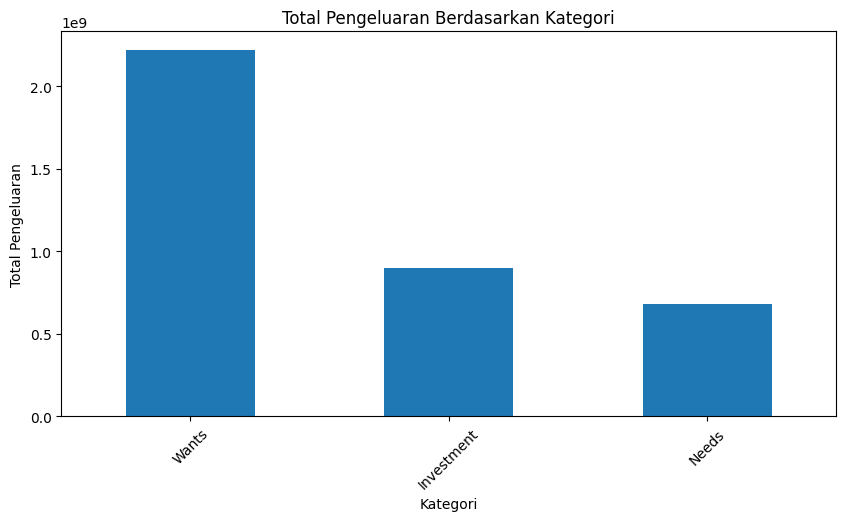

In [26]:
# Visualisasi pengeluaran per kategori
plt.figure(figsize=(10,5))

category_spending.plot(kind='bar')

plt.title('Total Pengeluaran Berdasarkan Kategori')
plt.xlabel('Kategori')
plt.ylabel('Total Pengeluaran')

plt.xticks(rotation=45)

plt.show()

**Insight**

Berdasarkan visualisasi total pengeluaran berdasarkan kategori, kategori *Wants* memiliki total pengeluaran tertinggi dibandingkan kategori lainnya, diikuti oleh *Investment* dan *Needs*. Hal ini menunjukkan bahwa sebagian besar transaksi pengguna cenderung dialokasikan untuk kebutuhan sekunder atau keinginan dibanding kebutuhan utama. Pola tersebut mengindikasikan adanya perilaku konsumtif pada pengguna, sehingga analisis kategori pengeluaran menjadi penting dalam mendukung fitur financial awareness dan predictive spending alert pada sistem.

In [27]:
# Distribusi per kategori
category_count = df_clean['category_primary'].value_counts()
print(category_count)

category_primary
Wants         4353
Needs         4328
Investment     898
Name: count, dtype: int64


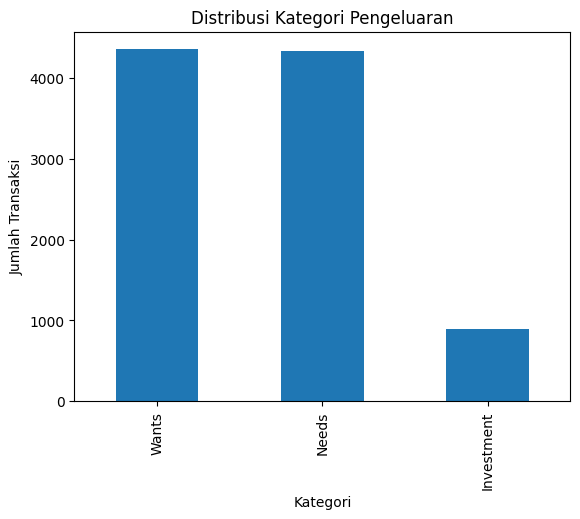

In [28]:
# Visualisasi distribusi per kategori
import matplotlib.pyplot as plt

category_count.plot(kind='bar')
plt.title("Distribusi Kategori Pengeluaran")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Transaksi")
plt.show()

**Insight**

Berdasarkan distribusi kategori pengeluaran, kategori *Wants* dan *Needs* memiliki jumlah transaksi yang hampir seimbang dan mendominasi keseluruhan aktivitas transaksi pengguna. Sementara itu, kategori *Investment* memiliki jumlah transaksi yang jauh lebih sedikit dibandingkan kategori lainnya. Hal ini menunjukkan bahwa sebagian besar pengguna lebih sering melakukan transaksi untuk kebutuhan dan keinginan sehari-hari dibandingkan aktivitas investasi. Pola tersebut mengindikasikan bahwa perilaku finansial pengguna masih didominasi oleh konsumsi dibandingkan pengelolaan keuangan jangka panjang.

In [29]:
# menambahkan kolom baru berdasarkan kolom date
df_clean['date'] = pd.to_datetime(df_clean['date'], format='%d/%m/%Y', errors='coerce')
df_clean['day_of_week'] = df_clean['date'].dt.day_name()
df_clean['month'] = df_clean['date'].dt.month
df_clean['is_weekend'] = df_clean['day_of_week'].isin(['Saturday', 'Sunday'])


In [30]:
# Trend waktu by harian
df_clean['date'] = pd.to_datetime(df_clean['date'])

daily_spending = df_clean.groupby('date')['amount'].sum()
daily_spending.head()

,amount
date,
2022-12-27 00:18:13,334000.0
2022-12-27 04:47:18,442500.0
2022-12-27 07:48:27,180000.0
2022-12-27 09:12:38,71000.0
2022-12-27 11:59:49,51000.0


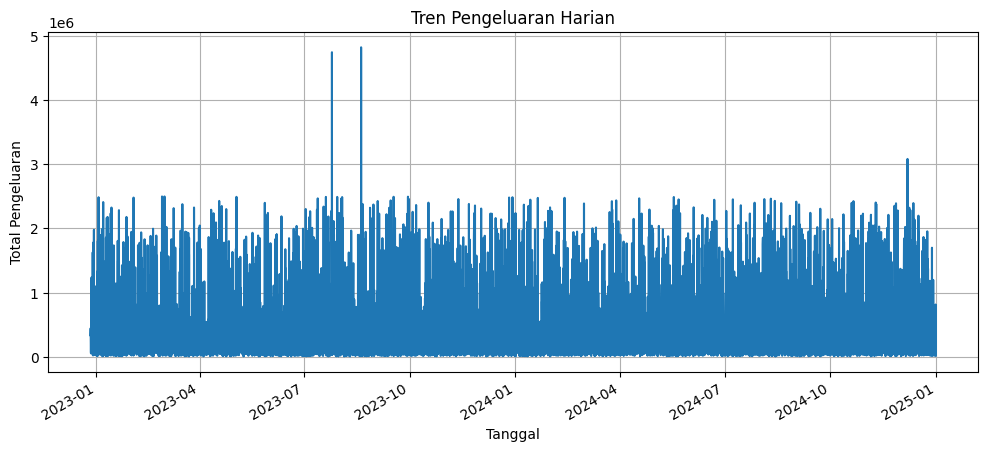

In [31]:
# Visualisasi trend waktu by harian
plt.figure(figsize=(12,5))

daily_spending.plot()

plt.title('Tren Pengeluaran Harian')
plt.xlabel('Tanggal')
plt.ylabel('Total Pengeluaran')

plt.grid(True)

plt.show()

**Insight**

Berdasarkan analisis tren pengeluaran harian, total transaksi pengguna mengalami fluktuasi pada berbagai waktu tertentu. Hal ini menunjukkan bahwa aktivitas pengeluaran pengguna tidak bersifat stabil dan dapat dipengaruhi oleh kebutuhan maupun perilaku konsumsi pada periode tertentu. Selain itu, penambahan fitur waktu seperti nama hari, bulan, dan kategori weekend memungkinkan analisis perilaku finansial dilakukan secara lebih mendalam, terutama untuk mengidentifikasi pola pengeluaran berdasarkan waktu transaksi.


Visualisasi tren pengeluaran harian menunjukkan bahwa aktivitas transaksi pengguna mengalami fluktuasi yang cukup dinamis sepanjang periode pengamatan. Beberapa titik pada grafik menunjukkan lonjakan pengeluaran yang signifikan dibanding hari lainnya, yang dapat mengindikasikan adanya transaksi bernilai besar atau perilaku overspending pada waktu tertentu. Secara umum, pola pengeluaran pengguna cenderung konsisten berada pada rentang tertentu, namun tetap memiliki variasi yang menunjukkan perubahan perilaku finansial dari waktu ke waktu. Analisis ini penting untuk mendukung pengembangan fitur behavior pattern detection dan predictive spending alert pada sistem.

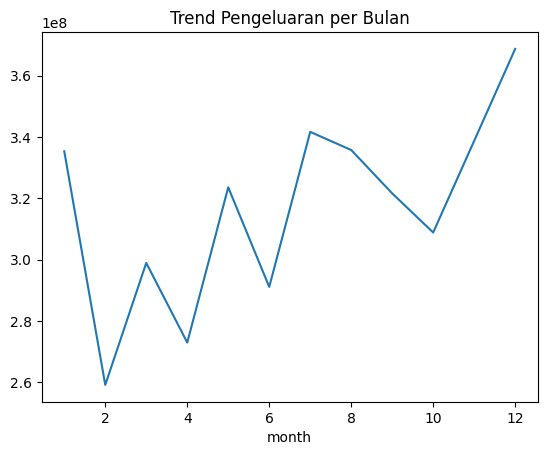

In [32]:
# Trend waktu by month
monthly_spending = df_clean.groupby('month')['amount'].sum()

monthly_spending.plot()
plt.title("Trend Pengeluaran per Bulan")
plt.show()

**Insight**

Berdasarkan tren pengeluaran bulanan, total pengeluaran pengguna mengalami fluktuasi sepanjang periode pengamatan. Beberapa bulan menunjukkan peningkatan pengeluaran yang cukup signifikan, terutama pada pertengahan hingga akhir tahun. Selain itu, terlihat adanya kenaikan pengeluaran pada bulan ke-12 yang menjadi titik pengeluaran tertinggi dibanding bulan lainnya. Pola ini mengindikasikan bahwa perilaku finansial pengguna dapat dipengaruhi oleh periode waktu tertentu, seperti kebutuhan musiman, aktivitas konsumtif, atau peningkatan transaksi pada akhir tahun. Analisis tren bulanan ini dapat membantu sistem dalam mendeteksi perubahan pola pengeluaran dan mendukung fitur predictive spending alert.

In [33]:
# Spending perbandingan weekday weekend
weekend_spending = df_clean.groupby('is_weekend')['amount'].mean()

print(weekend_spending)

is_weekend
False    394881.249084
True     399886.330674
Name: amount, dtype: float64


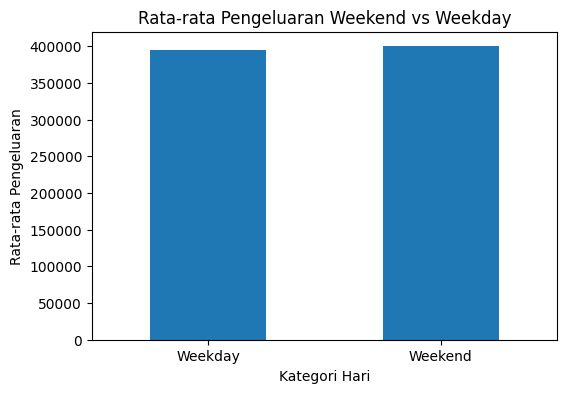

In [34]:
# Rata-rata pengeluaran weekend vs weekday

weekend_spending = df_clean.groupby('is_weekend')['amount'].mean()

weekend_spending.index = ['Weekday', 'Weekend']

plt.figure(figsize=(6,4))

weekend_spending.plot(kind='bar')

plt.title('Rata-rata Pengeluaran Weekend vs Weekday')
plt.xlabel('Kategori Hari')
plt.ylabel('Rata-rata Pengeluaran')

plt.xticks(rotation=0)

plt.show()

**Insight**

Berdasarkan perbandingan rata-rata pengeluaran antara weekday dan weekend, terlihat bahwa pengeluaran pengguna pada akhir pekan cenderung sedikit lebih tinggi dibandingkan hari kerja. Meskipun perbedaannya tidak terlalu signifikan, pola ini menunjukkan adanya kecenderungan peningkatan aktivitas konsumsi saat akhir pekan. Hal tersebut dapat dipengaruhi oleh aktivitas hiburan, belanja, maupun kebutuhan rekreasi pengguna pada waktu luang. Analisis ini mendukung pengembangan fitur behavior pattern detection untuk mengidentifikasi pola pengeluaran berdasarkan waktu transaksi.

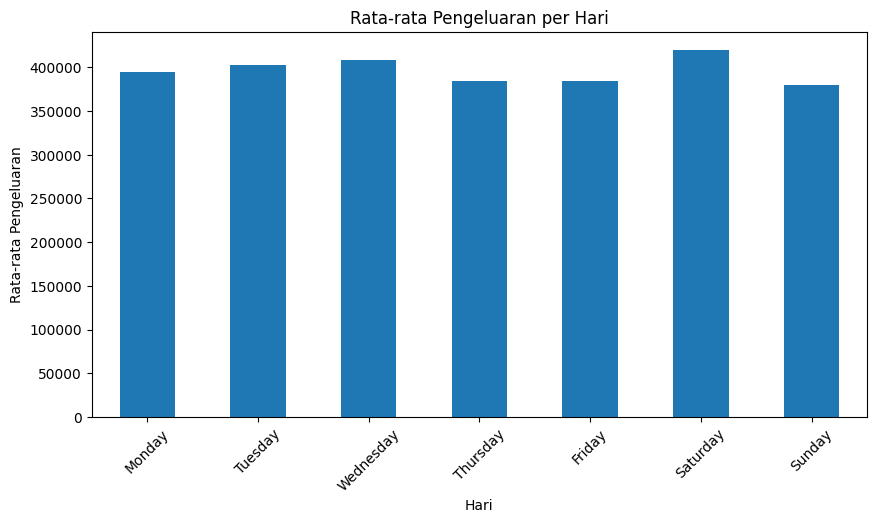

In [35]:
# Visualisasi spending per day name
day_spending = df_clean.groupby('day_of_week')['amount'].mean()

day_spending = day_spending.reindex([
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
])

plt.figure(figsize=(10,5))

day_spending.plot(kind='bar')

plt.title('Rata-rata Pengeluaran per Hari')
plt.xlabel('Hari')
plt.ylabel('Rata-rata Pengeluaran')

plt.xticks(rotation=45)

plt.show()

**Insight**

Berdasarkan rata-rata pengeluaran per hari, terlihat bahwa aktivitas transaksi pengguna cenderung relatif stabil sepanjang minggu dengan perbedaan nominal yang tidak terlalu signifikan. Namun, hari Sabtu memiliki rata-rata pengeluaran tertinggi dibandingkan hari lainnya, yang mengindikasikan adanya peningkatan aktivitas konsumsi pada akhir pekan. Sementara itu, hari Kamis dan Minggu menunjukkan rata-rata pengeluaran yang relatif lebih rendah. Pola ini menunjukkan bahwa perilaku finansial pengguna dapat dipengaruhi oleh waktu dan aktivitas harian tertentu, sehingga analisis temporal menjadi penting dalam mendukung fitur behavior pattern detection dan predictive spending alert.

In [36]:
# Top Merchant
top_merchant = df_clean['merchant'].value_counts().head(10)
print(top_merchant)

merchant
MyXL                    240
Pintu Crypto             97
Pluang                   91
Biznet                   91
PLN Mobile               90
Adobe Creative Cloud     90
BPJS Kesehatan           87
MyTelkomsel              87
Tabungan BRI             85
First Media              85
Name: count, dtype: int64


**Insight**

Berdasarkan analisis top merchant, platform *MyXL* menjadi merchant dengan jumlah transaksi tertinggi dibandingkan merchant lainnya, diikuti oleh layanan digital seperti *Pintu Crypto*, *Pluang*, dan *Adobe Creative Cloud*. Selain itu, beberapa merchant yang berkaitan dengan kebutuhan harian dan layanan utilitas seperti *PLN Mobile*, *BPJS Kesehatan*, dan *Tabungan BRI* juga termasuk dalam transaksi yang sering digunakan pengguna. Pola ini menunjukkan bahwa aktivitas transaksi pengguna didominasi oleh layanan digital, utilitas, serta platform finansial dan hiburan. Analisis merchant dapat membantu sistem dalam memahami preferensi pengguna dan mendukung fitur behavior pattern detection maupun personalized financial insight.

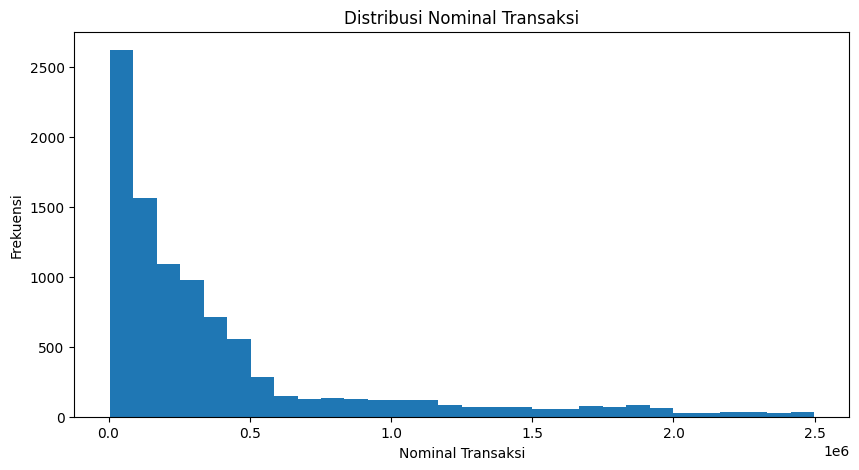

In [37]:
# Histogram Distribusi Amount

plt.figure(figsize=(10,5))

plt.hist(df_clean['amount'], bins=30)

plt.title('Distribusi Nominal Transaksi')
plt.xlabel('Nominal Transaksi')
plt.ylabel('Frekuensi')

plt.show()

**Insight**

Distribusi nominal transaksi menunjukkan pola right-skewed, di mana sebagian besar transaksi berada pada nominal rendah hingga menengah, sementara hanya sebagian kecil transaksi yang memiliki nominal sangat tinggi. Hal ini menunjukkan bahwa pengguna lebih sering melakukan transaksi harian dengan nilai kecil, seperti kebutuhan konsumsi atau pembayaran rutin. Selain itu, terdapat beberapa transaksi dengan nominal tinggi yang dapat dikategorikan sebagai outlier dan berpotensi merepresentasikan aktivitas overspending atau transaksi khusus pada periode tertentu. Pola distribusi ini penting untuk mendukung analisis perilaku finansial serta pengembangan fitur predictive spending alert pada sistem.

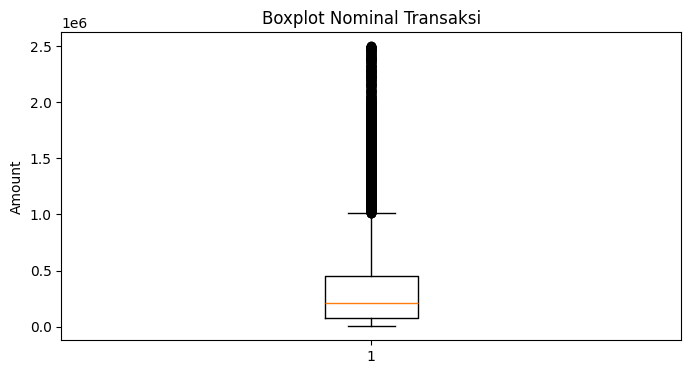

In [38]:
# Boxplot
plt.figure(figsize=(8,4))

plt.boxplot(df_clean['amount'])

plt.title('Boxplot Nominal Transaksi')
plt.ylabel('Amount')

plt.show()

**Insight**

Berdasarkan boxplot nominal transaksi, sebagian besar transaksi pengguna berada pada rentang nominal rendah hingga menengah, yang ditunjukkan oleh posisi median dan distribusi data utama pada boxplot. Namun, terdapat banyak titik outlier dengan nominal transaksi yang jauh lebih tinggi dibandingkan mayoritas data lainnya. Hal ini menunjukkan adanya transaksi bernilai besar yang terjadi pada waktu tertentu dan berpotensi merepresentasikan perilaku overspending atau pengeluaran tidak rutin. Keberadaan outlier ini menjadi indikator penting dalam analisis perilaku finansial pengguna serta dapat dimanfaatkan untuk mendukung pengembangan fitur predictive spending alert dan financial behavior analysis pada sistem.

In [39]:
# Top User dengan Pengeluaran Tertinggi
user_spending = df_clean.groupby('user_id')['amount'].sum().sort_values(ascending=False).head(10)

user_spending

,amount
user_id,
USR007,67861000.0
USR037,64306500.0
USR002,62528000.0
USR038,61739500.0
USR015,60845500.0
USR008,60294500.0
USR068,59732500.0
USR029,59374000.0
USR065,59002500.0


**Insight**

Analisis top user dengan pengeluaran tertinggi menunjukkan bahwa terdapat beberapa pengguna yang memiliki total pengeluaran jauh lebih besar dibandingkan pengguna lainnya. User *USR007* menjadi pengguna dengan total pengeluaran tertinggi, diikuti oleh beberapa user lain dengan nilai transaksi yang relatif tinggi dan berdekatan. Pola ini menunjukkan adanya perbedaan perilaku finansial antar pengguna, di mana sebagian pengguna memiliki tingkat konsumsi yang lebih tinggi dibandingkan pengguna lainnya. Analisis ini penting untuk mendukung fitur behavior pattern detection dan financial scoring, karena sistem dapat mengidentifikasi pengguna dengan potensi perilaku overspending maupun pola pengeluaran tertentu berdasarkan histori transaksi mereka.

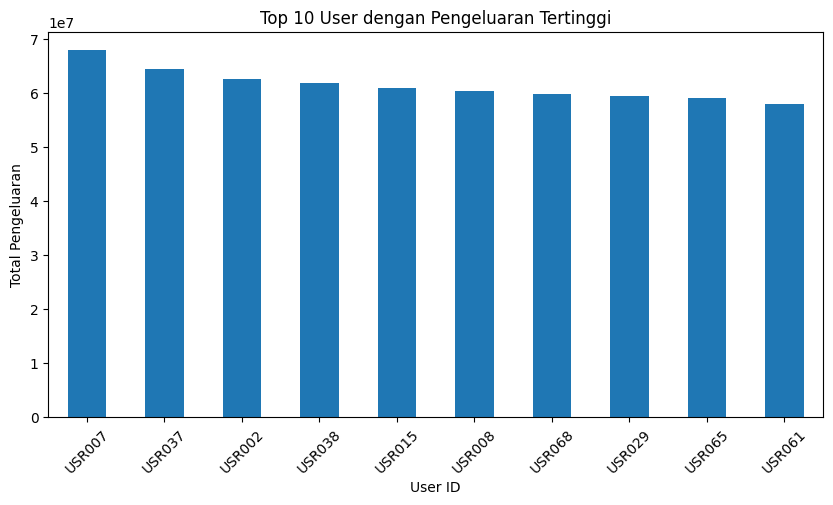

In [40]:
# Visualisasi top user
plt.figure(figsize=(10,5))

user_spending.plot(kind='bar')

plt.title('Top 10 User dengan Pengeluaran Tertinggi')
plt.xlabel('User ID')
plt.ylabel('Total Pengeluaran')

plt.xticks(rotation=45)

plt.show()

**Insight**

Visualisasi top 10 user dengan pengeluaran tertinggi menunjukkan bahwa terdapat beberapa pengguna dengan tingkat pengeluaran yang relatif tinggi dan cukup berdekatan satu sama lain. User *USR007* memiliki total pengeluaran tertinggi dibandingkan pengguna lainnya, diikuti oleh *USR037* dan *USR002*. Meskipun terdapat perbedaan nominal antar pengguna, distribusi pengeluaran pada kelompok top user terlihat cukup stabil tanpa selisih yang terlalu ekstrem. Hal ini menunjukkan bahwa beberapa pengguna memiliki pola konsumsi yang aktif dan konsisten dalam melakukan transaksi. Analisis ini dapat membantu sistem dalam mengidentifikasi perilaku finansial pengguna, terutama untuk mendukung fitur behavior pattern detection, financial scoring, dan predictive spending alert.

## Feature Engineering

In [41]:
# Feature waktu
df_clean['day_of_week'] = df_clean['date'].dt.day_name()
df_clean['day'] = df_clean['date'].dt.day
df_clean['month'] = df_clean['date'].dt.month
df_clean['week'] = df_clean['date'].dt.isocalendar().week
df_clean['is_weekend'] = df_clean['day_of_week'].isin(['Saturday', 'Sunday'])

In [42]:
# menambahkan kolom baru untuk kategori waktu (Pagi, Siang, Sore, Malam) dari kolom date
def get_time_of_day(hour):
    if 5 <= hour < 12: return 'Pagi'
    elif 12 <= hour < 17: return 'Siang'
    elif 17 <= hour < 20: return 'Sore'
    else: return 'Malam'

df_clean['time_of_day'] = df_clean['date'].dt.hour.apply(get_time_of_day)

print(df_clean[['date', 'time_of_day']].head())

                 date time_of_day
0 2024-10-03 20:33:48       Malam
1 2024-12-03 05:09:38        Pagi
2 2024-02-19 20:15:58       Malam
3 2023-11-18 01:04:49       Malam
4 2024-01-05 19:15:44        Sore


**Insight**

Pada tahap feature engineering, dilakukan penambahan beberapa fitur berbasis waktu untuk mendukung analisis perilaku finansial pengguna. Fitur seperti *day_of_week*, *day*, *month*, dan *week* digunakan untuk mengidentifikasi pola transaksi berdasarkan waktu, sedangkan fitur *is_weekend* digunakan untuk membedakan aktivitas transaksi pada hari kerja dan akhir pekan. Selain itu, dibuat fitur *time_of_day* yang mengelompokkan waktu transaksi ke dalam kategori Pagi, Siang, Sore, dan Malam. Penambahan fitur-fitur ini bertujuan untuk membantu sistem dalam mendeteksi pola perilaku pengguna secara lebih mendalam, seperti kecenderungan waktu transaksi, kebiasaan belanja, serta potensi perilaku overspending berdasarkan periode tertentu.

In [43]:
# Feature Nominal 1
def categorize_amount(x):
    if x < 50000:
        return 'low'
    elif x < 200000:
        return 'medium'
    else:
        return 'high'

df_clean['spending_level'] = df_clean['amount'].apply(categorize_amount)

In [44]:
# Feature Nominal 2 - Log transform
df_clean['log_amount'] = np.log1p(df_clean['amount'])

In [45]:
# Feature Behavior - transaksi terakhir
df_clean = df_clean.sort_values('date')

df_clean['rolling_7d_spending'] = df_clean['amount'].rolling(window=7).sum()

In [46]:
# Feature Behavior 2 - Transaction Frequency
df_clean['transaction_count'] = df_clean.groupby('date')['amount'].transform('count')

**Insight**

Pada tahap feature engineering, dilakukan penambahan fitur berbasis nominal transaksi dan perilaku pengguna untuk mendukung analisis finansial yang lebih mendalam. Fitur *spending_level* digunakan untuk mengelompokkan transaksi ke dalam kategori rendah, menengah, dan tinggi berdasarkan nominal transaksi, sehingga sistem dapat mengenali tingkat pengeluaran pengguna dengan lebih mudah. Selain itu, dilakukan transformasi logaritmik melalui fitur *log_amount* untuk membantu menstabilkan distribusi data transaksi yang cenderung memiliki banyak outlier.  

Untuk mendukung analisis perilaku pengguna, ditambahkan fitur *rolling_7d_spending* yang merepresentasikan akumulasi pengeluaran dalam 7 transaksi terakhir, sehingga sistem dapat mendeteksi pola peningkatan pengeluaran secara bertahap. Selain itu, fitur *transaction_count* digunakan untuk menghitung frekuensi transaksi pengguna berdasarkan waktu tertentu. Penambahan fitur-fitur ini bertujuan untuk meningkatkan kemampuan sistem dalam melakukan behavior pattern detection, predictive spending alert, serta financial scoring secara lebih akurat.

### Feature Engineering Result

In [47]:
df_clean.head()

,transaction_id,user_id,date,merchant,amount,category_detail,category_primary,payment_method,payment_media,day_of_week,month,is_weekend,day,week,time_of_day,spending_level,log_amount,rolling_7d_spending,transaction_count
4190,TXN004191,USR051,2022-12-27 00:18:13,PLN Mobile,334000.0,utilities,Needs,Transfer,DANA,Tuesday,12,False,27,52,Malam,high,12.718899,NaN,1
57,TXN000058,USR015,2022-12-27 04:47:18,Pluang,442500.0,investment,Investment,Transfer,DANA,Tuesday,12,False,27,52,Malam,high,13.000198,NaN,1
6944,TXN006945,USR062,2022-12-27 07:48:27,Giant,180000.0,groceries,Needs,Debit,BCA,Tuesday,12,False,27,52,Pagi,medium,12.100718,NaN,1
7876,TXN007877,USR003,2022-12-27 09:12:38,WeTV,71000.0,entertainment,Wants,Cash,Cash,Tuesday,12,False,27,52,Pagi,medium,11.170449,NaN,1
7696,TXN007697,USR036,2022-12-27 11:59:49,Blue Bird,51000.0,transport,Needs,QRIS,BCA,Tuesday,12,False,27,52,Pagi,medium,10.839601,NaN,1


**Insight**

Hasil feature engineering menunjukkan bahwa dataset telah berhasil diperkaya dengan berbagai fitur tambahan yang merepresentasikan aspek waktu, nominal transaksi, serta perilaku pengguna. Dataset kini tidak hanya memuat informasi transaksi dasar seperti merchant, kategori, dan metode pembayaran, tetapi juga fitur analisis seperti *day_of_week*, *time_of_day*, *spending_level*, *rolling_7d_spending*, dan *transaction_count*.  

Penambahan fitur-fitur tersebut memungkinkan sistem untuk melakukan analisis perilaku finansial secara lebih mendalam, seperti mengidentifikasi waktu transaksi yang paling aktif, tingkat pengeluaran pengguna, pola peningkatan spending dalam periode tertentu, serta frekuensi transaksi pengguna. Dengan adanya feature engineering ini, dataset menjadi lebih siap digunakan untuk proses analisis behavior pattern detection, predictive spending alert, financial scoring, maupun pengembangan model machine learning pada sistem SADAR Finance.

In [48]:
# Cek 7 baris terakhir
df_clean.tail(7)

,transaction_id,user_id,date,merchant,amount,category_detail,category_primary,payment_method,payment_media,day_of_week,month,is_weekend,day,week,time_of_day,spending_level,log_amount,rolling_7d_spending,transaction_count
1074,TXN001075,USR043,2024-12-31 17:00:27,KRL Commuter,38500.0,transport,Needs,Debit,BCA,Tuesday,12,False,31,1,Sore,low,10.558439,1349500.0,1
9337,TXN009338,USR067,2024-12-31 18:38:00,iPot,813000.0,investment,Investment,QRIS,LinkAja,Tuesday,12,False,31,1,Sore,high,13.608488,2034000.0,1
199,TXN000200,USR018,2024-12-31 18:40:05,Klinik Pratama,63500.0,health,Needs,QRIS,OVO,Tuesday,12,False,31,1,Sore,medium,11.058811,1984500.0,1
6404,TXN006405,USR014,2024-12-31 20:53:45,Timezone,186000.0,entertainment,Wants,QRIS,DANA,Tuesday,12,False,31,1,Malam,medium,12.133507,1912500.0,1
4736,TXN004737,USR052,2024-12-31 21:02:03,Blue Bird,34000.0,transport,Needs,Debit,BSI,Tuesday,12,False,31,1,Malam,low,10.434145,1717000.0,1
2813,TXN002814,USR035,2024-12-31 21:25:12,Warteg,10500.0,food,Needs,QRIS,DANA,Tuesday,12,False,31,1,Malam,low,9.259226,1347500.0,1
5232,TXN005233,USR049,2024-12-31 23:28:44,Netflix,164000.0,entertainment,Wants,QRIS,Mandiri,Tuesday,12,False,31,1,Malam,medium,12.007628,1309500.0,1


## Analisis Behavior

In [49]:
# WEEKDAY vs WEEKEND
df_clean.groupby('is_weekend')['amount'].mean()

,amount
is_weekend,
False,394881.249084
True,399886.330674


In [50]:
# SPENDING PER HARI
df_clean.groupby('day_of_week')['amount'].mean().sort_values()

,amount
day_of_week,
Sunday,380077.454545
Thursday,383831.236121
Friday,384672.826087
Monday,394940.287770
Tuesday,402379.742033
Wednesday,408666.425470
Saturday,419580.621837


<Axes: xlabel='day_of_week'>

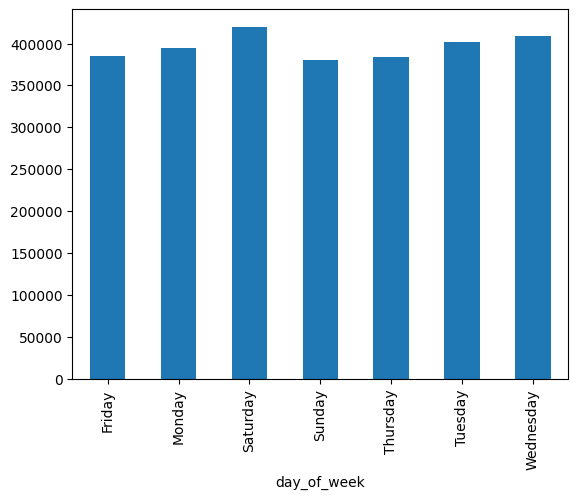

In [51]:
# VISUALISASI SPENDING PER HARI
df_clean.groupby('day_of_week')['amount'].mean().plot(kind='bar')

In [52]:
# KATEGORI PALING BOROS
df_clean.groupby('category_primary')['amount'].sum().sort_values(ascending=False)

,amount
category_primary,
Wants,2.220275e+09
Investment,8.957620e+08
Needs,6.803345e+08


In [53]:
# TREND SPENDING (ROLLING)
df_clean[['date','rolling_7d_spending']].tail(20)

,date,rolling_7d_spending
8248,2024-12-30 20:32:21,1084500.0
6927,2024-12-30 21:11:20,1165000.0
9738,2024-12-31 00:20:38,1351000.0
1590,2024-12-31 02:33:26,1568500.0
8713,2024-12-31 02:47:00,1647500.0
10026,2024-12-31 03:08:45,1214500.0
1981,2024-12-31 03:30:47,1177500.0
2941,2024-12-31 03:59:34,1256500.0
1120,2024-12-31 06:48:48,1226500.0
6998,2024-12-31 11:34:42,1254000.0


In [54]:
# BULANAN (BEHAVIOR WAKTU)
df_clean.groupby('month')['amount'].sum()

,amount
month,
1,335314000.0
2,259192000.0
3,298951000.0
4,272990000.0
5,323578500.0
6,291132000.0
7,341637500.0
8,335732000.0
9,321599500.0


In [55]:
#  FREKUENSI TRANSAKSI
df_clean['day'].value_counts().sort_index()

,count
day,
1,289
2,333
3,311
4,350
5,312
6,318
7,297
8,311
9,316


**Insight**

Hasil analisis behavior menunjukkan bahwa rata-rata pengeluaran pengguna pada akhir pekan cenderung lebih tinggi dibandingkan hari kerja, meskipun perbedaannya tidak terlalu signifikan. Selain itu, berdasarkan rata-rata pengeluaran per hari, hari Sabtu menjadi hari dengan aktivitas pengeluaran tertinggi, sedangkan hari Minggu dan Kamis memiliki rata-rata pengeluaran yang relatif lebih rendah. Pola ini mengindikasikan bahwa perilaku konsumsi pengguna meningkat pada akhir pekan, yang kemungkinan dipengaruhi oleh aktivitas hiburan, belanja, maupun kebutuhan rekreasi.  

Dari sisi kategori pengeluaran, kategori *Wants* menjadi kategori dengan total pengeluaran tertinggi dibandingkan *Needs* dan *Investment*. Hal ini menunjukkan bahwa sebagian besar aktivitas transaksi pengguna masih didominasi oleh kebutuhan sekunder atau konsumsi non-prioritas. Selain itu, analisis rolling spending menunjukkan adanya fluktuasi akumulasi pengeluaran dalam beberapa transaksi terakhir, yang dapat digunakan untuk mendeteksi peningkatan spending secara bertahap maupun potensi overspending pada pengguna tertentu.  

Analisis bulanan juga menunjukkan bahwa pengeluaran pengguna mengalami fluktuasi sepanjang tahun, dengan peningkatan pengeluaran tertinggi terjadi pada bulan ke-12. Sementara itu, distribusi frekuensi transaksi harian menunjukkan pola transaksi yang relatif stabil pada sebagian besar tanggal dalam satu bulan. Secara keseluruhan, hasil analisis behavior ini menunjukkan bahwa waktu transaksi, kategori pengeluaran, dan intensitas spending memiliki pengaruh terhadap perilaku finansial pengguna. Insight tersebut dapat dimanfaatkan untuk mendukung pengembangan fitur behavior pattern detection, predictive spending alert, dan financial scoring pada sistem SADAR Finance.

## Visualisasi Data Pertanyaan Bisnis

In [56]:
# Import Library
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

### Pertanyaan 1 : Bagaimana distribusi pengeluaran user berdasarkan kategori dalam 3 bulan terakhir?


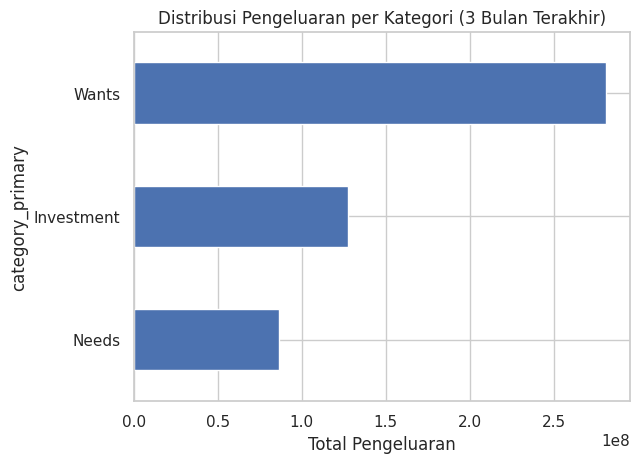

In [57]:
# DISTRIBUSI PENGELUARAN (3 BULAN TERAKHIR)
# ambil 3 bulan terakhir
last_3_months = df_clean[df_clean['date'] >= df_clean['date'].max() - pd.DateOffset(months=3)]

category_spending = last_3_months.groupby('category_primary')['amount'].sum().sort_values()

category_spending.plot(kind='barh')
plt.title('Distribusi Pengeluaran per Kategori (3 Bulan Terakhir)')
plt.xlabel('Total Pengeluaran')
plt.show()

#### Jawaban

Berdasarkan distribusi pengeluaran selama 3 bulan terakhir, kategori Wants memiliki total pengeluaran tertinggi, diikuti oleh Investment dan Needs. Hal ini menunjukkan bahwa sebagian besar pengeluaran pengguna masih didominasi oleh kebutuhan sekunder atau keinginan dibandingkan kebutuhan pokok dan investasi. Temuan ini mengindikasikan adanya potensi perilaku konsumtif yang perlu diperhatikan untuk mencegah terjadinya overspending.

### Pertanyaan 2 :   Kategori apa yang mengalami peningkatan pengeluaran terbesar dari bulan ke bulan?


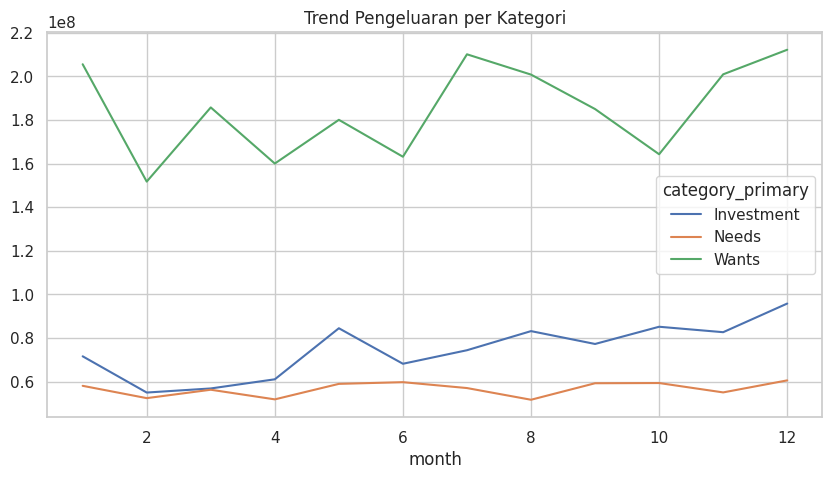

In [58]:
# KATEGORI PALING MENINGKAT
monthly_category = df_clean.groupby(['month', 'category_primary'])['amount'].sum().unstack()

monthly_category.plot(figsize=(10,5))
plt.title('Trend Pengeluaran per Kategori')
plt.show()

#### Jawaban

Berdasarkan tren pengeluaran bulanan, kategori Investment mengalami peningkatan yang paling konsisten dari bulan ke bulan. Total pengeluaran investasi meningkat dari sekitar Rp70 juta pada awal tahun menjadi hampir Rp100 juta pada bulan ke-12. Sementara itu, kategori Wants memiliki nilai pengeluaran terbesar, namun cenderung berfluktuasi, dan kategori Needs relatif stabil sepanjang periode pengamatan.

### Pertanyaan 3 : Pada hari apa transaksi paling sering terjadi?


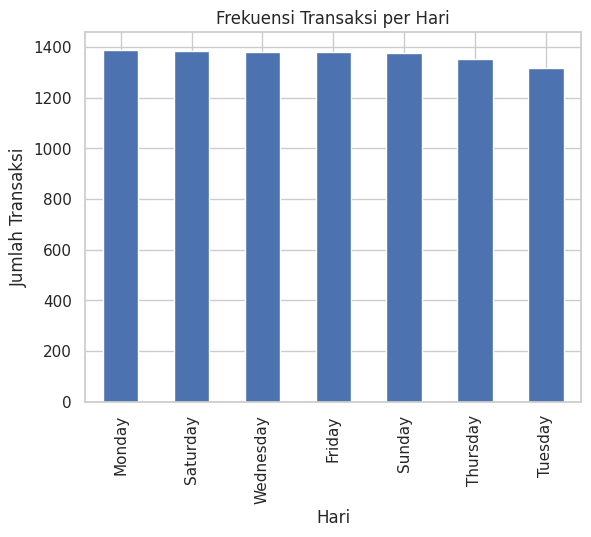

In [59]:
# HARI PALING SERING TRANSAKSI
day_freq = df_clean['day_of_week'].value_counts()

day_freq.plot(kind='bar')
plt.title('Frekuensi Transaksi per Hari')
plt.xlabel('Hari')
plt.ylabel('Jumlah Transaksi')
plt.show()

#### Jawaban

Berdasarkan grafik frekuensi transaksi per hari, Senin (Monday) merupakan hari dengan jumlah transaksi tertinggi. Namun, perbedaan frekuensi transaksi antar hari relatif kecil, yang menunjukkan bahwa aktivitas transaksi pengguna cenderung tersebar merata sepanjang minggu. Sementara itu, Selasa (Tuesday) menjadi hari dengan jumlah transaksi paling rendah.

### Pertanyaan 4 : Berapa rata-rata pengeluaran harian user dan bagaimana perubahannya dari waktu ke waktu?


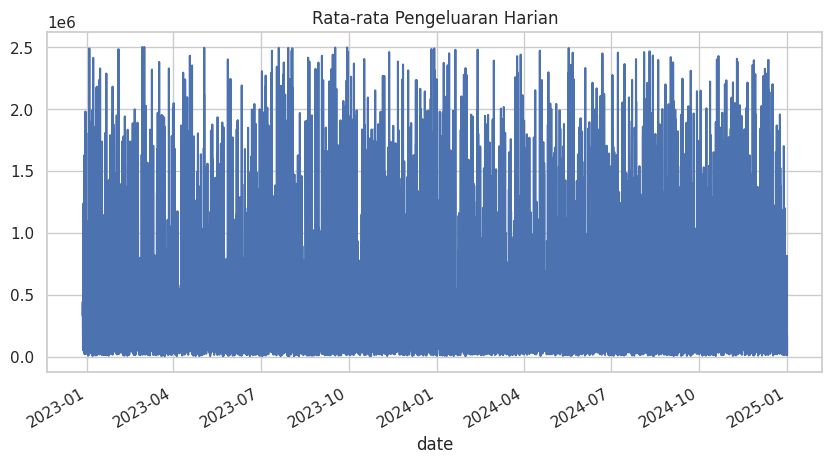

In [60]:
# RATA-RATA PENGELUARAN HARIAN
daily_spending = df_clean.groupby('date')['amount'].mean()

daily_spending.plot(figsize=(10,5))
plt.title('Rata-rata Pengeluaran Harian')
plt.show()

#### Jawaban

Berdasarkan grafik rata-rata pengeluaran harian, nilai pengeluaran pengguna berfluktuasi dari waktu ke waktu tanpa menunjukkan tren kenaikan maupun penurunan yang signifikan. Sebagian besar pengeluaran harian berada pada rentang Rp1–2,5 juta, dengan beberapa hari menunjukkan pengeluaran yang lebih rendah. Hal ini menunjukkan bahwa pola pengeluaran pengguna cenderung stabil meskipun terdapat variasi aktivitas transaksi pada hari-hari tertentu.


### Pertanyaan 5 : Kapan waktu paling berisiko user mengalami lonjakan pengeluaran?


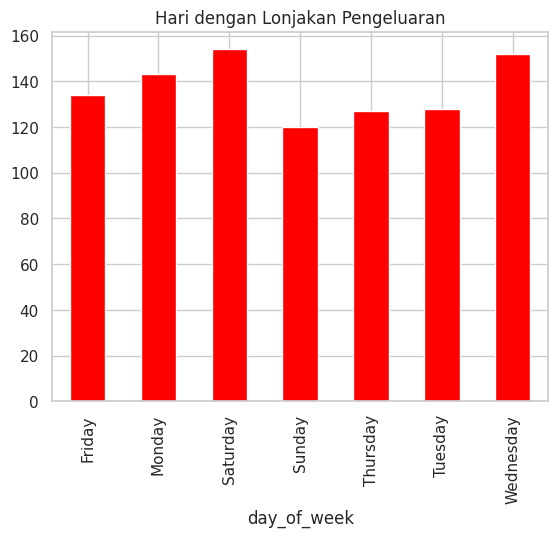

In [61]:
# WAKTU PALING BERISIKO
df_clean['spike'] = df_clean['amount'] > df_clean['amount'].quantile(0.9)

spike_by_day = df_clean.groupby('day_of_week')['spike'].sum()

spike_by_day.plot(kind='bar', color='red')
plt.title('Hari dengan Lonjakan Pengeluaran')
plt.show()

#### Jawaban

Berdasarkan grafik hari dengan lonjakan pengeluaran (spending spike), hari Sabtu merupakan waktu yang paling berisiko mengalami lonjakan pengeluaran, diikuti oleh Rabu dan Senin. Sebaliknya, Minggu memiliki jumlah lonjakan pengeluaran paling rendah. Temuan ini menunjukkan bahwa pengguna cenderung melakukan transaksi bernilai besar pada akhir pekan, khususnya hari Sabtu.


### Pertanyaan 6 : Apakah terdapat perbedaan rata-rata pengeluaran berdasarkan metode pembayaran?

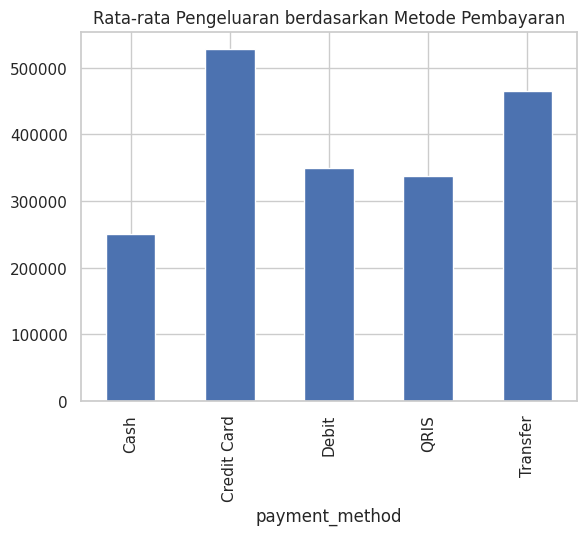

In [62]:
#METODE PEMBAYARAN vs SPENDING
payment_avg = df_clean.groupby('payment_method')['amount'].mean()

payment_avg.plot(kind='bar')
plt.title('Rata-rata Pengeluaran berdasarkan Metode Pembayaran')
plt.show()

#### Jawaban

Berdasarkan grafik rata-rata pengeluaran berdasarkan metode pembayaran, pengguna yang menggunakan Credit Card memiliki rata-rata pengeluaran tertinggi, diikuti oleh Transfer. Sementara itu, metode Cash menunjukkan rata-rata pengeluaran terendah. Hal ini mengindikasikan bahwa transaksi dengan kartu kredit cenderung digunakan untuk pengeluaran bernilai lebih besar dibandingkan metode pembayaran lainnya.

In [63]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9579 entries, 4190 to 5232
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transaction_id       9579 non-null   object        
 1   user_id              9579 non-null   object        
 2   date                 9579 non-null   datetime64[ns]
 3   merchant             9579 non-null   object        
 4   amount               9579 non-null   float64       
 5   category_detail      9579 non-null   object        
 6   category_primary     9579 non-null   object        
 7   payment_method       9579 non-null   object        
 8   payment_media        9579 non-null   object        
 9   day_of_week          9579 non-null   object        
 10  month                9579 non-null   int32         
 11  is_weekend           9579 non-null   bool          
 12  day                  9579 non-null   int32         
 13  week                 9579 non-null 

In [64]:
# simpan dataset untuk modeling
df_clean.to_csv("data_modelling.csv", index=False)